# Retail Sales EDA
This notebook performs exploratory data analysis on retail sales data.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("../dataset/retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


### Dataset Information
Display column names, data types, and non-null counts.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


### Descriptive Statistics
Generate summary statistics for numerical columns.

In [9]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


### Missing Values Check
Check whether the dataset contains missing values.

In [ ]:
df.isnull().sum()
#no null data

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

### Duplicate Records Check
Count duplicate rows in the dataset.

In [29]:
df.duplicated().sum()

np.int64(0)

### Remove Duplicate Records
Drop duplicate rows to improve data quality.

In [31]:
df.drop_duplicates(inplace=True)

### Date Conversion
Convert the Date column to datetime format for time-series analysis.

In [40]:
df['Date'] = pd.to_datetime(df['Date'])

### Mean Calculation
Calculate mean for numerical columns.

In [22]:
print(df.mean(numeric_only=True))

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64


### Median Calculation
Calculate median for numerical columns.

In [24]:
print(df.median(numeric_only=True))

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64


### Mode Calculation
Calculate the most frequent value in each column.

In [25]:
print(df.mode().iloc[0])

Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0
Product Category      Clothing
Quantity                   4.0
Price per Unit            50.0
Total Amount              50.0
Name: 0, dtype: object


### Standard Deviation
Measure the spread of numerical features.

In [26]:
print(df.std(numeric_only=True))

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


### Prepare Daily Sales Series
Aggregate total sales by date.

In [33]:
df['Date'] = pd.to_datetime(df['Date'])

daily_sales = df.groupby('Date')['Total Amount'].sum()

daily_sales.head()

Date
2023-01-01    3600
2023-01-02    1765
2023-01-03     600
2023-01-04    1240
2023-01-05    1100
Name: Total Amount, dtype: int64

### Daily Sales Trend
Visualize sales trend over time.

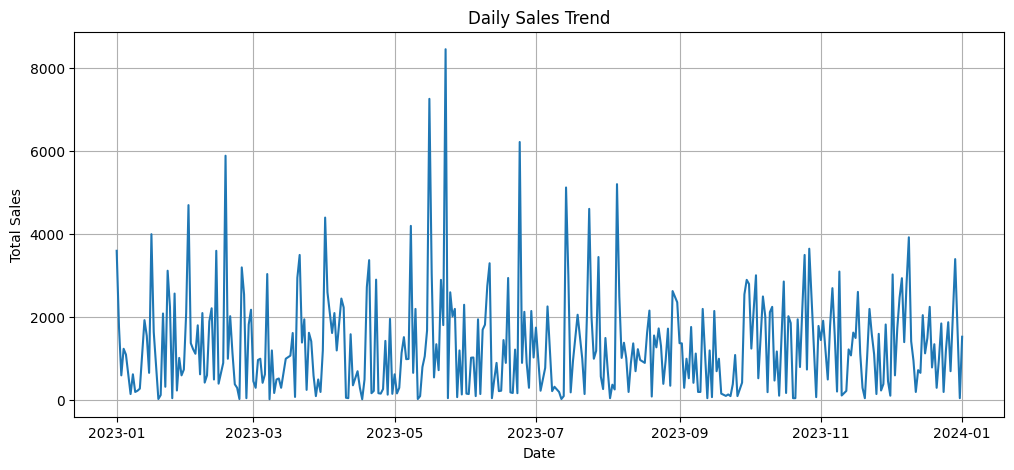

In [36]:
plt.figure(figsize=(12,5))

plt.plot(daily_sales)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

### Moving Average Trend
Smooth short-term fluctuations using a 7-day moving average.

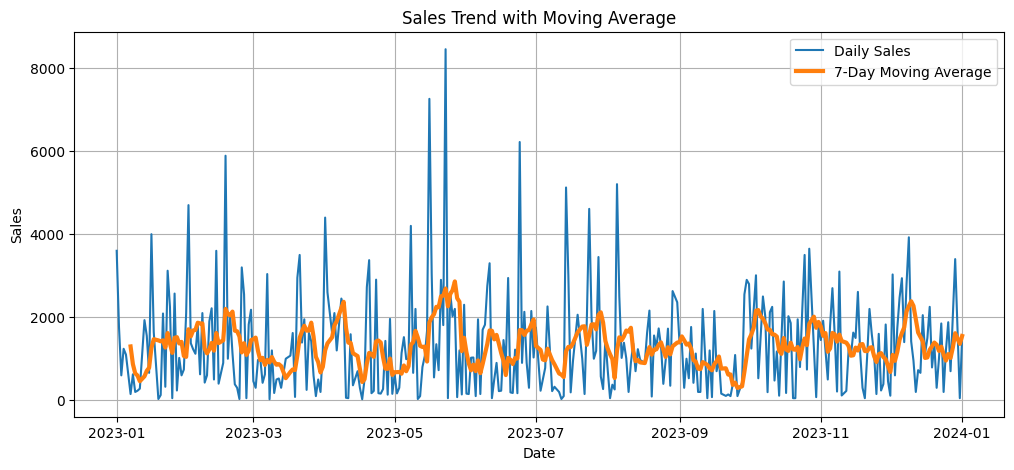

In [37]:
moving_avg = daily_sales.rolling(window=7).mean()

plt.figure(figsize=(12,5))

plt.plot(daily_sales, label='Daily Sales')
plt.plot(moving_avg,
         linewidth=3,
         label='7-Day Moving Average')

plt.title("Sales Trend with Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

### Monthly Sales Trend
Analyze sales aggregated by month.

C:\Users\pkush\AppData\Local\Temp\ipykernel_32712\1030152163.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M', on='Date')['Total Amount']


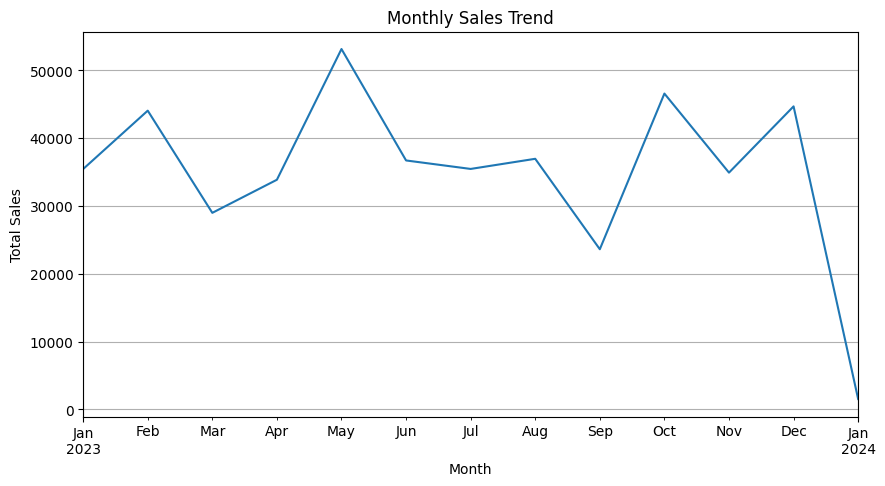

In [41]:
monthly_sales = (
    df.resample('M', on='Date')['Total Amount']
      .sum()
)

plt.figure(figsize=(10,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

### Seasonal Decomposition
Break sales into trend, seasonality, and residual components.

C:\Users\pkush\AppData\Local\Temp\ipykernel_32712\2703747538.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_sales = daily_sales.fillna(method='ffill')


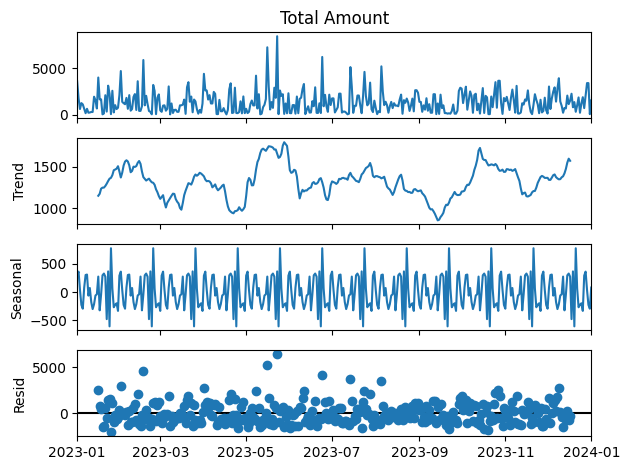

In [43]:
from statsmodels.tsa.seasonal import seasonal_decompose
daily_sales = daily_sales.asfreq('D')

daily_sales = daily_sales.fillna(method='ffill')
decomposition = seasonal_decompose(
    daily_sales,
    model='additive',
    period=30
)

decomposition.plot()

plt.show()

### Gender Distribution
Analyze customer demographics by gender.

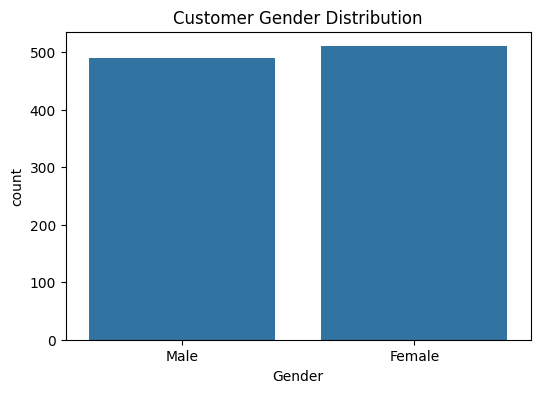

In [45]:
import seaborn as sns
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title('Customer Gender Distribution')
plt.show()

### Age Distribution
Visualize customer age groups.

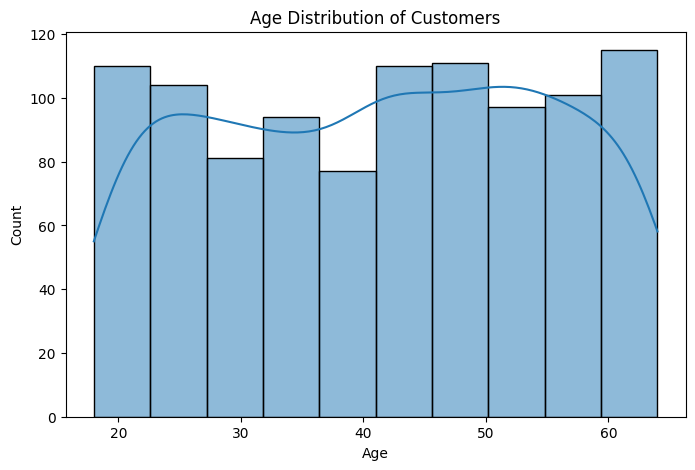

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=10, kde=True)

plt.title('Age Distribution of Customers')
plt.xlabel('Age')

plt.show()

### Spending by Gender
Compare average spending across genders.

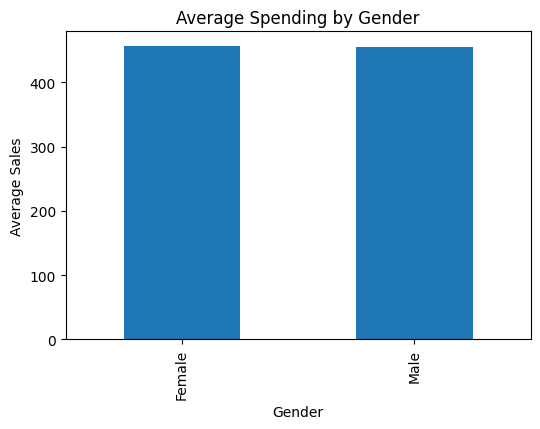

In [47]:
gender_sales = df.groupby('Gender')['Total Amount'].mean()

plt.figure(figsize=(6,4))

gender_sales.plot(kind='bar')

plt.title('Average Spending by Gender')
plt.ylabel('Average Sales')

plt.show()

### Age vs Purchase Amount
Explore relationship between age and spending.

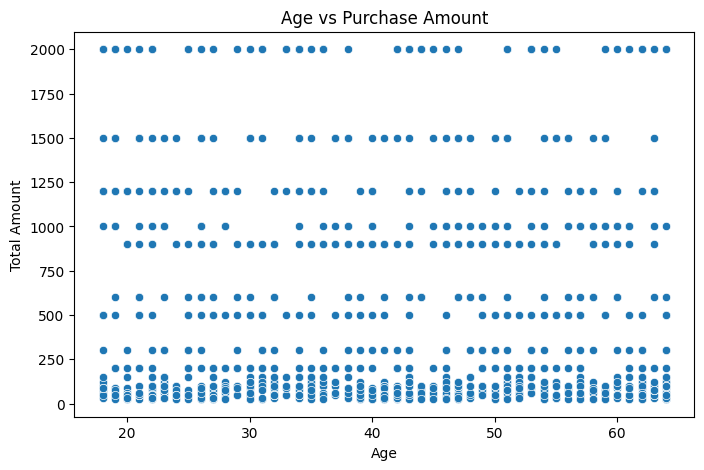

In [48]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='Total Amount',
    data=df
)

plt.title('Age vs Purchase Amount')

plt.show()

### Revenue by Product Category
Identify highest revenue-generating categories.

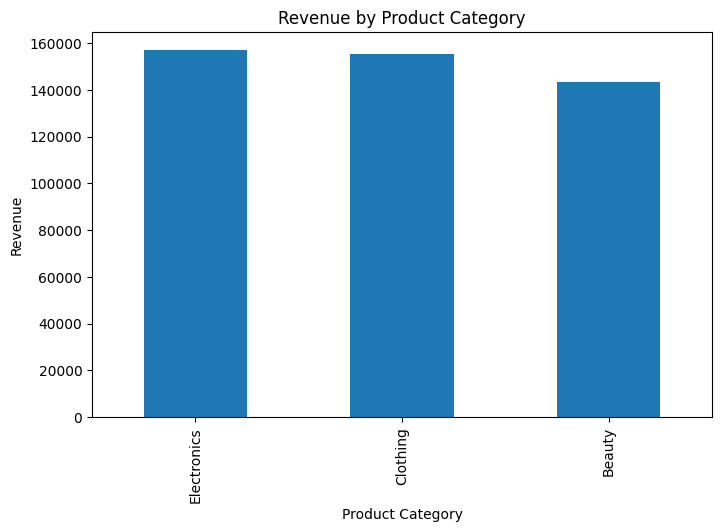

In [49]:
category_sales = (
    df.groupby('Product Category')['Total Amount']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.ylabel('Revenue')

plt.show()

### Quantity Sold by Category
Identify most purchased categories.

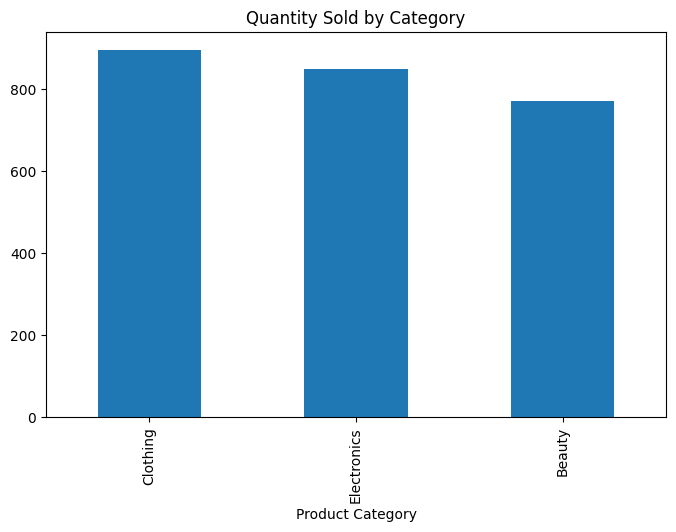

In [50]:
category_quantity = (
    df.groupby('Product Category')['Quantity']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_quantity.plot(kind='bar')

plt.title('Quantity Sold by Category')

plt.show()

### Average Order Value by Category
Compare average transaction values.

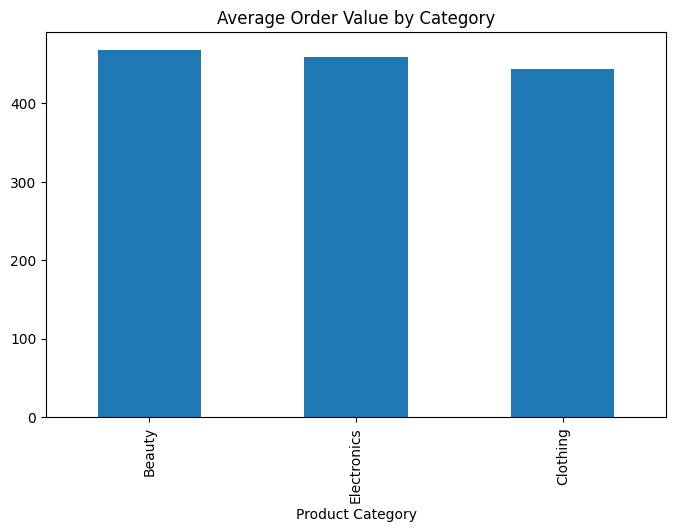

In [51]:
avg_order = (
    df.groupby('Product Category')['Total Amount']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

avg_order.plot(kind='bar')

plt.title('Average Order Value by Category')

plt.show()

### Correlation Heatmap
Analyze relationships among numerical features.

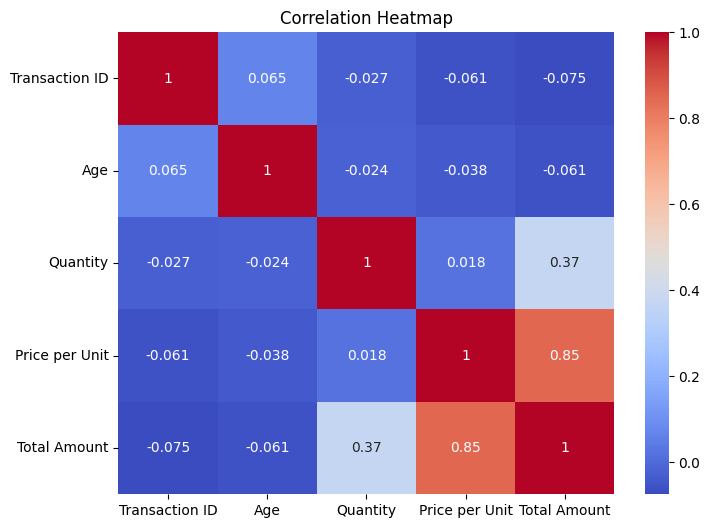

In [52]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

# Recommendations

1. Focus marketing campaigns on the highest revenue-generating product categories.
2. Target the dominant customer age group with personalized offers and promotions.
3. Increase inventory before periods showing higher sales trends.
4. Introduce loyalty programs to encourage repeat purchases.
5. Use seasonal sales patterns for demand forecasting and inventory planning.
6. Bundle or discount low-performing products to improve their sales.
7. Monitor customer purchasing behavior regularly to optimize product offerings.
